# 03. Baselines clásicos para detección AML

Este notebook tiene como objetivo construir modelos clásicos de clasificación binaria para detectar transacciones ilícitas en el dataset Elliptic.

Se utilizarán únicamente las transacciones etiquetadas como `licit` e `illicit`. Las transacciones `unknown` no se emplean como clase negativa, ya que representan nodos no etiquetados y no necesariamente transacciones lícitas.

Los modelos evaluados serán:

1. Logistic Regression.
2. Random Forest.
3. XGBoost.

Las métricas principales serán PR-AUC, ROC-AUC, recall, F1 y Recall@K, debido al fuerte desbalance de clases.

In [1]:
# Imports y rutas
import sys
from pathlib import Path
import json
import joblib

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

from xgboost import XGBClassifier

PROJECT_ROOT = Path.cwd().parents[0] if Path.cwd().name == "notebooks" else Path.cwd()
SRC_DIR = PROJECT_ROOT / "src"

if str(SRC_DIR) not in sys.path:
    sys.path.append(str(SRC_DIR))

from aml_gnn.utils.paths import INTERIM_DIR, MODELS_DIR, REPORTS_DIR, EXPERIMENTS_DIR
from aml_gnn.evaluation.metrics import evaluate_binary_classifier

print("PROJECT_ROOT:", PROJECT_ROOT)
print("INTERIM_DIR:", INTERIM_DIR)
print("MODELS_DIR:", MODELS_DIR)
print("REPORTS_DIR:", REPORTS_DIR)

PROJECT_ROOT: /home/lucho/aml-gnn-tesis
INTERIM_DIR: /home/lucho/aml-gnn-tesis/data/interim/elliptic
MODELS_DIR: /home/lucho/aml-gnn-tesis/models
REPORTS_DIR: /home/lucho/aml-gnn-tesis/reports


In [2]:
# Carga del dataset procesado con features del grafo
nodes_path = INTERIM_DIR / "nodes_with_graph_features.parquet"

nodes_df = pd.read_parquet(nodes_path)

print("Shape:", nodes_df.shape)
nodes_df.head()

Shape: (203769, 171)


,txId,timestep,f_0,f_1,f_2,f_3,f_4,f_5,f_6,f_7,...,f_159,f_160,f_161,f_162,f_163,f_164,label,in_degree,out_degree,total_degree
0,230425980,1,-0.171469,-0.184668,-1.201369,-0.121970,-0.043875,-0.113002,-0.061584,-0.162097,...,0.018279,-0.087490,-0.131155,-0.097524,-0.120613,-0.119792,unknown,1,1,2
1,5530458,1,-0.171484,-0.184668,-1.201369,-0.121970,-0.043875,-0.113002,-0.061584,-0.162112,...,0.018279,-0.087490,-0.131155,-0.097524,-0.120613,-0.119792,unknown,1,1,2
2,232022460,1,-0.172107,-0.184668,-1.201369,-0.121970,-0.043875,-0.113002,-0.061584,-0.162749,...,-0.098889,-0.106715,-0.131155,-0.183671,-0.120613,-0.119792,unknown,1,2,3
3,232438397,1,0.163054,1.963790,-0.646376,12.409294,-0.063725,9.782742,12.414558,-0.163645,...,1.072793,0.085530,-0.131155,0.677799,-0.120613,-0.119792,licit,160,1,161
4,230460314,1,1.011523,-0.081127,-1.201369,1.153668,0.333276,1.312656,-0.061584,-0.163523,...,0.018279,0.277775,0.326394,1.293750,0.178136,0.179117,unknown,2,8,10


In [3]:
# Filtrando solo las clases supervisadas
supervised_df = nodes_df[
    nodes_df["label"].isin(["licit", "illicit"])
].copy()

supervised_df["target"] = supervised_df["label"].map({
    "licit": 0,
    "illicit": 1
})

print("Dataset supervisado:", supervised_df.shape)

supervised_df["label"].value_counts()

Dataset supervisado: (46564, 172)


label
licit      42019
illicit     4545
Name: count, dtype: int64

In [4]:
# Distribucion porcentual del dataset supervisado
supervised_distribution = (
    supervised_df["label"]
    .value_counts()
    .rename_axis("label")
    .reset_index(name="count")
)

supervised_distribution["percentage"] = (
    supervised_distribution["count"] /
    supervised_distribution["count"].sum() * 100
).round(2)

supervised_distribution

,label,count,percentage
0,licit,42019,90.24
1,illicit,4545,9.76


## 4. Definición del split temporal

No uso un split aleatorio (es decir, no divido los datos de forma aleatoria). 
Dado que Elliptic tiene timestep, uso esta una división cronológica.

In [5]:
# Revisando timesteps disponibles
timesteps = sorted(supervised_df["timestep"].unique())

print("Mínimo timestep:", min(timesteps))
print("Máximo timestep:", max(timesteps))
print("Número de timesteps:", len(timesteps))
print("Timesteps:", timesteps)

Mínimo timestep: 1
Máximo timestep: 49
Número de timesteps: 49
Timesteps: [np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(9), np.int64(10), np.int64(11), np.int64(12), np.int64(13), np.int64(14), np.int64(15), np.int64(16), np.int64(17), np.int64(18), np.int64(19), np.int64(20), np.int64(21), np.int64(22), np.int64(23), np.int64(24), np.int64(25), np.int64(26), np.int64(27), np.int64(28), np.int64(29), np.int64(30), np.int64(31), np.int64(32), np.int64(33), np.int64(34), np.int64(35), np.int64(36), np.int64(37), np.int64(38), np.int64(39), np.int64(40), np.int64(41), np.int64(42), np.int64(43), np.int64(44), np.int64(45), np.int64(46), np.int64(47), np.int64(48), np.int64(49)]


In [6]:
# Creando un split temporal dinamico
unique_timesteps = np.array(sorted(supervised_df["timestep"].unique()))

n_timesteps = len(unique_timesteps)

train_end_idx = int(n_timesteps * 0.70)
val_end_idx = int(n_timesteps * 0.85)

train_timesteps = unique_timesteps[:train_end_idx]
val_timesteps = unique_timesteps[train_end_idx:val_end_idx]
test_timesteps = unique_timesteps[val_end_idx:]

print("Train timesteps:", train_timesteps)
print("Validation timesteps:", val_timesteps)
print("Test timesteps:", test_timesteps)

Train timesteps: [ 1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20 21 22 23 24
 25 26 27 28 29 30 31 32 33 34]
Validation timesteps: [35 36 37 38 39 40 41]
Test timesteps: [42 43 44 45 46 47 48 49]


In [7]:
# Asignar split
def assign_split(timestep):
    if timestep in train_timesteps:
        return "train"
    if timestep in val_timesteps:
        return "val"
    return "test"


supervised_df["split"] = supervised_df["timestep"].apply(assign_split)

split_summary = (
    supervised_df
    .groupby(["split", "label"])
    .size()
    .reset_index(name="count")
)

split_summary

,split,label,count
0,test,illicit,408
1,test,licit,8433
2,train,illicit,3462
3,train,licit,26432
4,val,illicit,675
5,val,licit,7154


In [8]:
# Tabla pivote del split
split_pivot = split_summary.pivot(
    index="split",
    columns="label",
    values="count"
).fillna(0).astype(int)

split_pivot["total"] = split_pivot.sum(axis=1)
split_pivot["illicit_percentage"] = (
    split_pivot["illicit"] / split_pivot["total"] * 100
).round(2)

split_pivot

label,illicit,licit,total,illicit_percentage
split,,,,
test,408,8433,8841,4.61
train,3462,26432,29894,11.58
val,675,7154,7829,8.62


## Seleccion de features

In [9]:
# Definiendo columnas de entrada
feature_cols = [
    col for col in supervised_df.columns
    if col.startswith("f_")
]

graph_feature_cols = [
    "in_degree",
    "out_degree",
    "total_degree"
]

feature_cols = feature_cols + graph_feature_cols

print("Número de features:", len(feature_cols))
print("Primeras features:", feature_cols[:10])
print("Últimas features:", feature_cols[-10:])

Número de features: 168
Primeras features: ['f_0', 'f_1', 'f_2', 'f_3', 'f_4', 'f_5', 'f_6', 'f_7', 'f_8', 'f_9']
Últimas features: ['f_158', 'f_159', 'f_160', 'f_161', 'f_162', 'f_163', 'f_164', 'in_degree', 'out_degree', 'total_degree']


No se usara como features a:
txId 
label
target
split
timestep

In [10]:
# Creando matrices train, validation y test
train_df = supervised_df[supervised_df["split"] == "train"].copy()
val_df = supervised_df[supervised_df["split"] == "val"].copy()
test_df = supervised_df[supervised_df["split"] == "test"].copy()

X_train = train_df[feature_cols]
y_train = train_df["target"]

X_val = val_df[feature_cols]
y_val = val_df["target"]

X_test = test_df[feature_cols]
y_test = test_df["target"]

print("X_train:", X_train.shape)
print("X_val:", X_val.shape)
print("X_test:", X_test.shape)

print("y_train distribución:")
print(y_train.value_counts(normalize=True).round(4))

print("y_val distribución:")
print(y_val.value_counts(normalize=True).round(4))

print("y_test distribución:")
print(y_test.value_counts(normalize=True).round(4))

X_train: (29894, 168)
X_val: (7829, 168)
X_test: (8841, 168)
y_train distribución:
target
0    0.8842
1    0.1158
Name: proportion, dtype: float64
y_val distribución:
target
0    0.9138
1    0.0862
Name: proportion, dtype: float64
y_test distribución:
target
0    0.9539
1    0.0461
Name: proportion, dtype: float64


## Modelo 1: Logistic Regression

In [11]:
# Entrenando Logistic Regression
logreg_model = Pipeline(
    steps=[
        ("scaler", StandardScaler()),
        ("classifier", LogisticRegression(
            max_iter=2000,
            class_weight="balanced",
            random_state=42,
            n_jobs=-1
        ))
    ]
)

logreg_model.fit(X_train, y_train)

val_score_logreg = logreg_model.predict_proba(X_val)[:, 1]
test_score_logreg = logreg_model.predict_proba(X_test)[:, 1]

logreg_val_metrics = evaluate_binary_classifier(y_val.to_numpy(), val_score_logreg)
logreg_test_metrics = evaluate_binary_classifier(y_test.to_numpy(), test_score_logreg)

logreg_test_metrics

/home/lucho/miniconda3/envs/gnn_tesis/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:1184: FutureWarning: 'n_jobs' has no effect since 1.8 and will be removed in 1.10. You provided 'n_jobs=-1', please leave it unspecified.
  warnings.warn(msg, category=FutureWarning)


{'accuracy': 0.7277457301210271,
 'precision': 0.12354048964218456,
 'recall': 0.803921568627451,
 'f1': 0.21416911524649038,
 'pr_auc': 0.19903740762801447,
 'roc_auc': 0.8552718312511771,
 'confusion_matrix': [[6106, 2327], [80, 328]],
 'classification_report': '              precision    recall  f1-score   support\n\n           0       0.99      0.72      0.84      8433\n           1       0.12      0.80      0.21       408\n\n    accuracy                           0.73      8841\n   macro avg       0.56      0.76      0.52      8841\nweighted avg       0.95      0.73      0.81      8841\n',
 'recall_at_50': np.float64(0.007352941176470588),
 'recall_at_100': np.float64(0.051470588235294115),
 'recall_at_500': np.float64(0.375),
 'recall_at_1000': np.float64(0.5171568627450981)}

In [12]:
# Mostrando reporte de clasificación de Logistic Regression
print(logreg_test_metrics["classification_report"])
print("Matriz de confusión:", logreg_test_metrics["confusion_matrix"])

              precision    recall  f1-score   support

           0       0.99      0.72      0.84      8433
           1       0.12      0.80      0.21       408

    accuracy                           0.73      8841
   macro avg       0.56      0.76      0.52      8841
weighted avg       0.95      0.73      0.81      8841

Matriz de confusión: [[6106, 2327], [80, 328]]


## Modelo 2: Random Forest

In [13]:
# Entrenando Random Forest
rf_model = RandomForestClassifier(
    n_estimators=300,
    max_depth=None,
    min_samples_split=2,
    min_samples_leaf=1,
    class_weight="balanced",
    random_state=42,
    n_jobs=-1
)

rf_model.fit(X_train, y_train)

val_score_rf = rf_model.predict_proba(X_val)[:, 1]
test_score_rf = rf_model.predict_proba(X_test)[:, 1]

rf_val_metrics = evaluate_binary_classifier(y_val.to_numpy(), val_score_rf)
rf_test_metrics = evaluate_binary_classifier(y_test.to_numpy(), test_score_rf)

rf_test_metrics

{'accuracy': 0.9740979527202805,
 'precision': 0.958974358974359,
 'recall': 0.4583333333333333,
 'f1': 0.6202321724709784,
 'pr_auc': 0.5475102669081868,
 'roc_auc': 0.8514482960265809,
 'confusion_matrix': [[8425, 8], [221, 187]],
 'classification_report': '              precision    recall  f1-score   support\n\n           0       0.97      1.00      0.99      8433\n           1       0.96      0.46      0.62       408\n\n    accuracy                           0.97      8841\n   macro avg       0.97      0.73      0.80      8841\nweighted avg       0.97      0.97      0.97      8841\n',
 'recall_at_50': np.float64(0.12254901960784313),
 'recall_at_100': np.float64(0.24509803921568626),
 'recall_at_500': np.float64(0.49019607843137253),
 'recall_at_1000': np.float64(0.5294117647058824)}

In [14]:
# Mostrando reporte de clasificación de Random Forest
print(rf_test_metrics["classification_report"])
print("Matriz de confusión:", rf_test_metrics["confusion_matrix"])

              precision    recall  f1-score   support

           0       0.97      1.00      0.99      8433
           1       0.96      0.46      0.62       408

    accuracy                           0.97      8841
   macro avg       0.97      0.73      0.80      8841
weighted avg       0.97      0.97      0.97      8841

Matriz de confusión: [[8425, 8], [221, 187]]


## Modelo 3: XGBoost

In [15]:
# Calcular scale_pos_weight
num_negative = int((y_train == 0).sum())
num_positive = int((y_train == 1).sum())

scale_pos_weight = num_negative / num_positive

print("Negativos train:", num_negative)
print("Positivos train:", num_positive)
print("scale_pos_weight:", scale_pos_weight)

Negativos train: 26432
Positivos train: 3462
scale_pos_weight: 7.634893125361063


In [16]:
# Entrenar XGBoost
xgb_model = XGBClassifier(
    n_estimators=400,
    max_depth=4,
    learning_rate=0.05,
    subsample=0.9,
    colsample_bytree=0.9,
    objective="binary:logistic",
    eval_metric="aucpr",
    scale_pos_weight=scale_pos_weight,
    random_state=42,
    n_jobs=-1
)

xgb_model.fit(
    X_train,
    y_train,
    eval_set=[(X_val, y_val)],
    verbose=False
)

val_score_xgb = xgb_model.predict_proba(X_val)[:, 1]
test_score_xgb = xgb_model.predict_proba(X_test)[:, 1]

xgb_val_metrics = evaluate_binary_classifier(y_val.to_numpy(), val_score_xgb)
xgb_test_metrics = evaluate_binary_classifier(y_test.to_numpy(), test_score_xgb)

xgb_test_metrics

{'accuracy': 0.9569053274516457,
 'precision': 0.5365853658536586,
 'recall': 0.4852941176470588,
 'f1': 0.5096525096525096,
 'pr_auc': 0.5614390083383461,
 'roc_auc': 0.8733779293764227,
 'confusion_matrix': [[8262, 171], [210, 198]],
 'classification_report': '              precision    recall  f1-score   support\n\n           0       0.98      0.98      0.98      8433\n           1       0.54      0.49      0.51       408\n\n    accuracy                           0.96      8841\n   macro avg       0.76      0.73      0.74      8841\nweighted avg       0.95      0.96      0.96      8841\n',
 'recall_at_50': np.float64(0.12254901960784313),
 'recall_at_100': np.float64(0.24509803921568626),
 'recall_at_500': np.float64(0.5049019607843137),
 'recall_at_1000': np.float64(0.5588235294117647)}

In [17]:
# Mostrando reporte de clasificación de XGBoost
print(xgb_test_metrics["classification_report"])
print("Matriz de confusión:", xgb_test_metrics["confusion_matrix"])


              precision    recall  f1-score   support

           0       0.98      0.98      0.98      8433
           1       0.54      0.49      0.51       408

    accuracy                           0.96      8841
   macro avg       0.76      0.73      0.74      8841
weighted avg       0.95      0.96      0.96      8841

Matriz de confusión: [[8262, 171], [210, 198]]


## Comparación de modelos

In [18]:
# Creando tabla comparativa
def compact_metrics(model_name, metrics_dict, split):
    return {
        "model": model_name,
        "split": split,
        "accuracy": metrics_dict["accuracy"],
        "precision": metrics_dict["precision"],
        "recall": metrics_dict["recall"],
        "f1": metrics_dict["f1"],
        "pr_auc": metrics_dict["pr_auc"],
        "roc_auc": metrics_dict["roc_auc"],
        "recall_at_50": metrics_dict["recall_at_50"],
        "recall_at_100": metrics_dict["recall_at_100"],
        "recall_at_500": metrics_dict["recall_at_500"],
        "recall_at_1000": metrics_dict["recall_at_1000"],
    }


metrics_rows = [
    compact_metrics("Logistic Regression", logreg_val_metrics, "validation"),
    compact_metrics("Logistic Regression", logreg_test_metrics, "test"),
    compact_metrics("Random Forest", rf_val_metrics, "validation"),
    compact_metrics("Random Forest", rf_test_metrics, "test"),
    compact_metrics("XGBoost", xgb_val_metrics, "validation"),
    compact_metrics("XGBoost", xgb_test_metrics, "test"),
]

metrics_df = pd.DataFrame(metrics_rows)

metrics_df

,model,split,accuracy,precision,recall,f1,pr_auc,roc_auc,recall_at_50,recall_at_100,recall_at_500,recall_at_1000
0,Logistic Regression,validation,0.751948,0.245480,0.905185,0.386220,0.381816,0.896093,0.038519,0.057778,0.342222,0.625185
1,Logistic Regression,test,0.727746,0.123540,0.803922,0.214169,0.199037,0.855272,0.007353,0.051471,0.375000,0.517157
2,Random Forest,validation,0.986588,0.998252,0.845926,0.915798,0.931044,0.979875,0.074074,0.148148,0.740741,0.900741
3,Random Forest,test,0.974098,0.958974,0.458333,0.620232,0.547510,0.851448,0.122549,0.245098,0.490196,0.529412
4,XGBoost,validation,0.978797,0.870451,0.885926,0.878120,0.934686,0.980047,0.074074,0.148148,0.739259,0.915556
5,XGBoost,test,0.956905,0.536585,0.485294,0.509653,0.561439,0.873378,0.122549,0.245098,0.504902,0.558824


In [19]:
# Ordenar por PR-AUC en test
metrics_df[metrics_df["split"] == "test"].sort_values(
    by="pr_auc",
    ascending=False
)

,model,split,accuracy,precision,recall,f1,pr_auc,roc_auc,recall_at_50,recall_at_100,recall_at_500,recall_at_1000
5,XGBoost,test,0.956905,0.536585,0.485294,0.509653,0.561439,0.873378,0.122549,0.245098,0.504902,0.558824
3,Random Forest,test,0.974098,0.958974,0.458333,0.620232,0.547510,0.851448,0.122549,0.245098,0.490196,0.529412
1,Logistic Regression,test,0.727746,0.123540,0.803922,0.214169,0.199037,0.855272,0.007353,0.051471,0.375000,0.517157


## Guardando resultados y modelos

In [ ]:
# Guardando metricas
metrics_dir = REPORTS_DIR / "metrics"
tables_dir = REPORTS_DIR / "tables"
experiment_dir = EXPERIMENTS_DIR / "01_baselines_clasicos"

metrics_dir.mkdir(parents=True, exist_ok=True)
tables_dir.mkdir(parents=True, exist_ok=True)
experiment_dir.mkdir(parents=True, exist_ok=True)

metrics_table_path = tables_dir / "baseline_model_comparison.csv"
metrics_df.to_csv(metrics_table_path, index=False)

metrics_json_path = metrics_dir / "baseline_metrics.json"

metrics_json = {
    "logistic_regression": {
        "validation": logreg_val_metrics,
        "test": logreg_test_metrics,
    },
    "random_forest": {
        "validation": rf_val_metrics,
        "test": rf_test_metrics,
    },
    "xgboost": {
        "validation": xgb_val_metrics,
        "test": xgb_test_metrics,
    },
}

with open(metrics_json_path, "w", encoding="utf-8") as file:
    json.dump(metrics_json, file, indent=4, ensure_ascii=False)

print("Guardado:", metrics_table_path)
print("Guardado:", metrics_json_path)

Guardado: /home/lucho/aml-gnn-tesis/reports/tables/baseline_model_comparison.csv
Guardado: /home/lucho/aml-gnn-tesis/reports/metrics/baseline_metrics.json


In [21]:
# Guardando modelos
MODELS_DIR.mkdir(parents=True, exist_ok=True)

joblib.dump(logreg_model, MODELS_DIR / "baseline_logistic_regression.pkl")
joblib.dump(rf_model, MODELS_DIR / "baseline_random_forest.pkl")
joblib.dump(xgb_model, MODELS_DIR / "baseline_xgboost.pkl")

print("Modelos guardados en:", MODELS_DIR)

Modelos guardados en: /home/lucho/aml-gnn-tesis/models


## Grafico comparativo

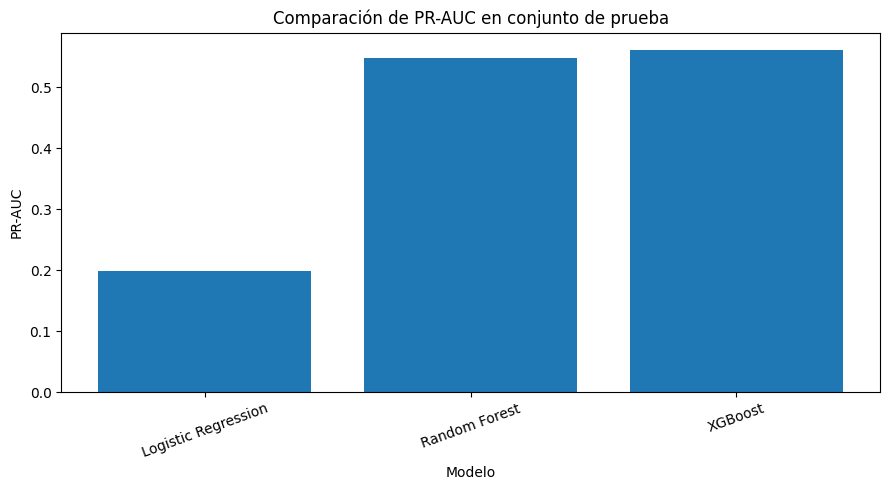

Guardado: /home/lucho/aml-gnn-tesis/reports/figures/baseline_pr_auc_comparison.png


In [22]:
# Comparando PR-AUC y Recall
test_metrics_df = metrics_df[metrics_df["split"] == "test"].copy()

plt.figure(figsize=(9, 5))
plt.bar(test_metrics_df["model"], test_metrics_df["pr_auc"])
plt.title("Comparación de PR-AUC en conjunto de prueba")
plt.xlabel("Modelo")
plt.ylabel("PR-AUC")
plt.xticks(rotation=20)
plt.tight_layout()

figures_dir = REPORTS_DIR / "figures"
figures_dir.mkdir(parents=True, exist_ok=True)

pr_auc_fig_path = figures_dir / "baseline_pr_auc_comparison.png"
plt.savefig(pr_auc_fig_path, dpi=300)
plt.show()

print("Guardado:", pr_auc_fig_path)

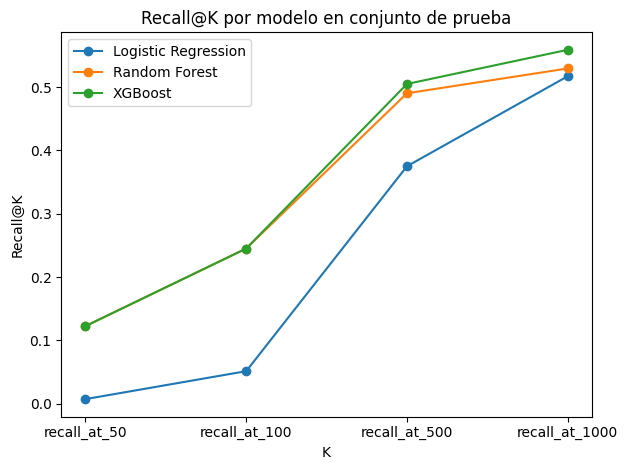

Guardado: /home/lucho/aml-gnn-tesis/reports/figures/baseline_recall_at_k_comparison.png


In [23]:
# Comparando Recall@K
recall_k_cols = ["recall_at_50", "recall_at_100", "recall_at_500", "recall_at_1000"]

for model_name in test_metrics_df["model"]:
    row = test_metrics_df[test_metrics_df["model"] == model_name].iloc[0]
    plt.plot(recall_k_cols, row[recall_k_cols], marker="o", label=model_name)

plt.title("Recall@K por modelo en conjunto de prueba")
plt.xlabel("K")
plt.ylabel("Recall@K")
plt.legend()
plt.tight_layout()

recall_k_fig_path = figures_dir / "baseline_recall_at_k_comparison.png"
plt.savefig(recall_k_fig_path, dpi=300)
plt.show()

print("Guardado:", recall_k_fig_path)

In [24]:
# Baseline ganador
best_baseline = metrics_df[metrics_df["split"] == "test"].sort_values(
    by="pr_auc",
    ascending=False
).iloc[0]

best_baseline

model              XGBoost
split                 test
accuracy          0.956905
precision         0.536585
recall            0.485294
f1                0.509653
pr_auc            0.561439
roc_auc           0.873378
recall_at_50      0.122549
recall_at_100     0.245098
recall_at_500     0.504902
recall_at_1000    0.558824
Name: 5, dtype: object

In [25]:
best_baseline_path = REPORTS_DIR / "metrics" / "best_baseline_model.json"

best_baseline_summary = {
    "selected_metric": "pr_auc",
    "best_model": best_baseline["model"],
    "split": best_baseline["split"],
    "pr_auc": float(best_baseline["pr_auc"]),
    "roc_auc": float(best_baseline["roc_auc"]),
    "precision": float(best_baseline["precision"]),
    "recall": float(best_baseline["recall"]),
    "f1": float(best_baseline["f1"]),
    "reason": (
        "Se selecciona el modelo con mayor PR-AUC en test, "
        "debido al desbalance de clases y al objetivo de detección AML."
    )
}

with open(best_baseline_path, "w", encoding="utf-8") as file:
    json.dump(best_baseline_summary, file, indent=4, ensure_ascii=False)

print("Guardado:", best_baseline_path)

Guardado: /home/lucho/aml-gnn-tesis/reports/metrics/best_baseline_model.json
